# Simulating different telescopes
This notebooks provides examples in how to use the lenstronomy.SimulationAPI modules in simulating (realistic) mock lenses taylored to a specific observation and instrument and makes a montage of different telescope settings currently available.

The module enables to use the astronomical magnitude conventions and can translate those into the lenstronomy core module configurations.

In [1]:
import copy
import os
import numpy as np
import scipy
from PIL import Image
import matplotlib.pyplot as plt
%matplotlib inline


# lenstronomy module import
from lenstronomy.Util import image_util, data_util, util
import lenstronomy.Plots.plot_util as plot_util
from lenstronomy.SimulationAPI.sim_api import SimAPI
# lenstronomy imports
from lenstronomy.LensModel.lens_model import LensModel
from lenstronomy.LensModel.Solver.lens_equation_solver import LensEquationSolver
from lenstronomy.LightModel.light_model import LightModel
from lenstronomy.PointSource.point_source import PointSource
from lenstronomy.ImSim.image_model import ImageModel
import lenstronomy.Util.param_util as param_util
import lenstronomy.Util.simulation_util as sim_util
import lenstronomy.Util.image_util as image_util
from lenstronomy.Util import kernel_util
from lenstronomy.Data.imaging_data import ImageData
from lenstronomy.Data.psf import PSF

import sncosmo
from astropy.table import Table

## SNCOSMO code

In [12]:
obs = Table({'time': [56176.19, 56188.254, 56207.172],
             'band': ['desg', 'desr', 'desi'],          #filters we are observing in 
             'gain': [1., 1., 1.],                      #dw 
             'skynoise': [0, 0, 0],      #depends on exposure time, but will be addig noise later in lenstronomy, could set to 0
             'zp': [30., 30., 30.],                     # zero point, what corresponds to 0 flux in this image - pixel values to magnitudes 
             'zpsys':['ab', 'ab', 'ab']})               # ab magnitudes, units of zero point
# print (obs)

# Will be observing in g and r band
# for now set to highest redshift that it will allow

model = sncosmo.Model(source='salt2')
params = {'z': 0.915, 't0': 56200.0, 'x0':1.e-5, 'x1': 0.1, 'c': -0.1}   #what are the last 3 params

lcs = sncosmo.realize_lcs(obs, model, [params])


flux_values = np.array(lcs[0]['flux'])
zero_points = np.array(obs['zp'])
magnitudes = zero_points - 2.5 * np.log10(flux_values)

print(magnitudes)

[27.14518078 23.03017531 22.50939146]


## Define camera and observations
As an example, we define the camera and observational settings of a LSST-like observation. We define one camera setting and three different observations corresponding to g,r,i imaging.

For the complete list of possible settings, we refer to the SimulationAPI.observation_api classes. There are pre-configured settings which approximately mimic observations from current and future instruments. Be careful using those and check whether they are sufficiently accurate for your specific science case!

In [82]:
# Instrument setting from pre-defined configurations

from lenstronomy.SimulationAPI.ObservationConfig.DES import DES
from lenstronomy.SimulationAPI.ObservationConfig.LSST import LSST
from lenstronomy.SimulationAPI.ObservationConfig.Euclid import Euclid
from lenstronomy.SimulationAPI.ObservationConfig.Roman import Roman


Roman_g = Roman(band='F062', psf_type='PIXEL', survey_mode='wide_area')
Roman_r = Roman(band='F106', psf_type='PIXEL', survey_mode='wide_area')
Roman_i = Roman(band='F184', psf_type='PIXEL', survey_mode='wide_area')
roman = [Roman_g, Roman_r, Roman_i]

# lenstronomy provides these setting to be imported with the SimulationAPI.ObservationConfig routines.



In [83]:
import lenstronomy.SimulationAPI.ObservationConfig

# List all available observation configurations in lenstronomy
print(dir(lenstronomy.SimulationAPI.ObservationConfig))

'''
no rubin?
euclid only takes 'VIS' for bands
'''

['DES', 'Euclid', 'LSST', 'Roman', '__builtins__', '__cached__', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__path__', '__spec__']


"\nno rubin?\neuclid only takes 'VIS' for bands\n"

## Define model settings

The model settings are handled by the SimulationAPI.model_api ModelAPI class. 
The role is to return instances of the lenstronomy LightModel, LensModel, PointSource modules according to the options chosen by the user. Currently, all other model choices are equivalent to the ones provided by LightModel, LensModel, PointSource.
The current options of the class instance only describe a subset of possibilities and we refer to the specific class instances for details about all the possibilities.

For this example, we chose a single lens plane and a single source plane, elliptical Sersic profile for the deflector, the interpolated Galaxy as the source and an additional lensed point source.

In [84]:
## I put in the defaults from the time_delay_cosmography except for point source ##

kwargs_model = {'lens_model_list': ['EPL', 'SHEAR'],  # list of lens models to be used
                'lens_light_model_list': ['SERSIC_ELLIPSE'],  # list of unlensed light models to be used
                'source_light_model_list': ['SERSIC_ELLIPSE'],  # list of extended source models to be used, here we used the interpolated real galaxy
                'point_source_model_list': ['SOURCE_POSITION']  # list of point source models to be used
    }

## Brightness definitions in magnitude space
One core feature is the support of light profile amplitudes in astronomical magnitude space (at least for few selected well defined brightness profiles).

We first define all parameters in magnitude space and then use the SimAPI routine to translate the arguments into lenstronomy conventions used by the ImSim module. The second model of each light component we defined as 'INTERPOL', which sets an interpolation grid given an image. This can be used to past real galaxies as lenses or sources into lenstronomy.

/home/vk9342/.conda/envs/usrp/lib/python3.11/site-packages/lenstronomy/LensModel/lens_model.py:96: UserWarning: Astropy Cosmology is provided. Make sure your cosmology model is consistent with the cosmology_model argument.
  warnings.warn(
/home/vk9342/.conda/envs/usrp/lib/python3.11/site-packages/lenstronomy/LensModel/Profiles/epl.py:297: RuntimeWarning: invalid value encountered in divide
  R_omega = Z * hyp2f1(1, t / 2, 2 - t / 2, -(1 - q) / (1 + q) * (Z / Z.conj()))


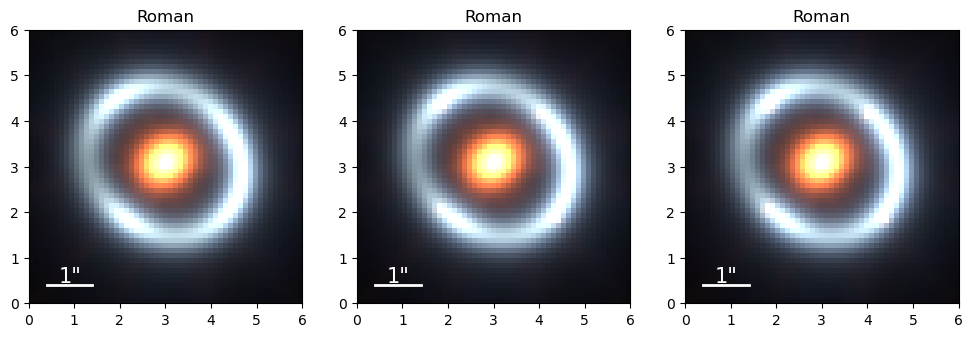

In [85]:
f, axes = plt.subplots(1, 3, figsize=(12, 4))

for i, mag in enumerate(magnitudes):

    # g-band
    '''
    amp or magnitude
    '''
    
    ### FOREGROUND GALAXY ####
    phi_G, q = 0.5, 0.8
    e1, e2 = param_util.phi_q2_ellipticity(phi_G, q)
    source_x = 0.
    source_y = 0.1
    # lens light
    kwargs_lens_light_mag_g = [{'magnitude': 15, 'R_sersic': 0.2, 'n_sersic': 1, 'e1': e1, 'e2': e2, 'center_x': source_x, 'center_y': source_y}]
    
    #### SN HOST GALAXY #####
    # source light
    # kwargs_source_mag_g = [{'magnitude': 19, 'image': ngc_data_resized, 'center_x': 0, 'center_y': 0, 'phi_G': 0, 'scale': 0.005}]
    phi_G, q = 0.9, 0.9
    e1, e2 = param_util.phi_q2_ellipticity(phi_G, q)
    kwargs_source_mag_g = [{'magnitude': 19, 'R_sersic': 0.2, 'n_sersic': 1, 'e1': e1, 'e2': e2, 'center_x': source_x, 'center_y': source_y}]
    # Note: this one was using INTERPOL and a preexisting image, I just changed it to the settings i time_delay_cosmography
    
    
    ### SUPERNOVA ####
    # point source
    kwargs_ps_mag_g = [{'magnitude': mag, 'ra_source': 0.03, 'dec_source': 0}]

    # doesnt take params such as redshift into account??
    # these are set as the lense_model params in time delay cosmography
    
    ### setting lens model parameters ####
    '''
    And finally we need a lens model. 
    The default lensing units are in 
    observed deflection angle (arc seconds) 
    mapping the image to the source plane (reduced angles). 
    In a single lens and single source plane model, 
    this is all we need to specify and no futher cosmology is required.
    '''
    gamma1, gamma2 = param_util.shear_polar2cartesian(phi=-0.5, gamma=0.06)
    kwargs_lens = [
        {'theta_E': 1.66, 'gamma': 1.98, 'center_x': 0.0, 'center_y': 0.0, 'e1': 0.05, 'e2': 0.05},  # spemd model
        {'gamma1': gamma1, 'gamma2': gamma2}  # SHEAR model
    ]
    
    
    
    # and now we define the colors of the other two bands
    # r-band
    g_r_source = 1  # color mag_g - mag_r for source
    g_r_lens = -1  # color mag_g - mag_r for lens light
    g_r_ps = 0
    kwargs_lens_light_mag_r = copy.deepcopy(kwargs_lens_light_mag_g)
    kwargs_lens_light_mag_r[0]['magnitude'] -= g_r_lens
    
    kwargs_source_mag_r = copy.deepcopy(kwargs_source_mag_g)
    kwargs_source_mag_r[0]['magnitude'] -= g_r_source
    
    kwargs_ps_mag_r = copy.deepcopy(kwargs_ps_mag_g)
    kwargs_ps_mag_r[0]['magnitude'] -= g_r_ps
    
    
    # i-band
    g_i_source = 2
    g_i_lens = -2
    g_i_ps = 0
    kwargs_lens_light_mag_i = copy.deepcopy(kwargs_lens_light_mag_g)
    kwargs_lens_light_mag_i[0]['magnitude'] -= g_i_lens
    
    kwargs_source_mag_i = copy.deepcopy(kwargs_source_mag_g)
    kwargs_source_mag_i[0]['magnitude'] -= g_i_source
    
    kwargs_ps_mag_i = copy.deepcopy(kwargs_ps_mag_g) 
    kwargs_ps_mag_i[0]['magnitude'] -= g_i_ps
    
    
    
    
    '''
    ## SIMULATE IMAGE
    Finally we can simulate the images with 
    the ImageModel class instance and the lenstronomy parameters 
    for the different bands. 
    Note that in the specific example we included a point source 
    (representing a quasar) in the center of the lensed galaxy. 
    The SimulationAPI supports various options. 
    Further down below we simulate multi-lens multi-source plane configurations too.
    '''
    
    numpix = 64  # number of pixels per axis of the image to be modelled
    
    # here we define the numerical options used in the ImSim module. 
    # Have a look at the ImageNumerics class for detailed descriptions.
    # If not further specified, the default settings are used.
    kwargs_numerics = {'point_source_supersampling_factor': 1}
    
    
    def simulate_rgb(ConfigList, size, kwargs_numerics):
        band_b, band_g, band_r = ConfigList
        kwargs_b_band = band_b.kwargs_single_band()
        kwargs_g_band = band_g.kwargs_single_band()
        kwargs_r_band = band_r.kwargs_single_band()
        
        # set number of pixels from pixel scale
        pixel_scale = kwargs_g_band['pixel_scale']
        numpix = int(round(size / pixel_scale))
    
        sim_b = SimAPI(numpix=numpix, kwargs_single_band=kwargs_b_band, kwargs_model=kwargs_model)
        sim_g = SimAPI(numpix=numpix, kwargs_single_band=kwargs_g_band, kwargs_model=kwargs_model)
        sim_r = SimAPI(numpix=numpix, kwargs_single_band=kwargs_r_band, kwargs_model=kwargs_model)
    
        # return the ImSim instance. With this class instance, you can compute all the
        # modelling accessible of the core modules. See class documentation and other notebooks.
        imSim_b = sim_b.image_model_class(kwargs_numerics)
        imSim_g = sim_g.image_model_class(kwargs_numerics)
        imSim_r = sim_r.image_model_class(kwargs_numerics)
    
    
        # turn magnitude kwargs into lenstronomy kwargs
    
        kwargs_lens_light_g, kwargs_source_g, kwargs_ps_g = sim_b.magnitude2amplitude(kwargs_lens_light_mag_g, kwargs_source_mag_g, kwargs_ps_mag_g)
        kwargs_lens_light_r, kwargs_source_r, kwargs_ps_r = sim_g.magnitude2amplitude(kwargs_lens_light_mag_r, kwargs_source_mag_r, kwargs_ps_mag_r)
        kwargs_lens_light_i, kwargs_source_i, kwargs_ps_i = sim_r.magnitude2amplitude(kwargs_lens_light_mag_i, kwargs_source_mag_i, kwargs_ps_mag_i)
    
    
        image_b = imSim_b.image(kwargs_lens, kwargs_source_g, kwargs_lens_light_g, kwargs_ps_g)
        image_g = imSim_g.image(kwargs_lens, kwargs_source_r, kwargs_lens_light_r, kwargs_ps_r)
        image_r = imSim_r.image(kwargs_lens, kwargs_source_i, kwargs_lens_light_i, kwargs_ps_i)
    
        # add noise
        image_b += sim_b.noise_for_model(model=image_b)
        image_g += sim_g.noise_for_model(model=image_g)
        image_r += sim_r.noise_for_model(model=image_r)
    
        # and plot it
    
        img = np.zeros((image_g.shape[0], image_g.shape[1], 3), dtype=float)
        #scale_max=10000
        def _scale_max(image): 
            flat=image.flatten()
            flat.sort()
            scale_max = flat[int(len(flat)*0.95)]
            return scale_max
        img[:,:,0] = plot_util.sqrt(image_b, scale_min=0, scale_max=_scale_max(image_b))
        img[:,:,1] = plot_util.sqrt(image_g, scale_min=0, scale_max=_scale_max(image_g))
        img[:,:,2] = plot_util.sqrt(image_r, scale_min=0, scale_max=_scale_max(image_r))
        data_class = sim_b.data_class
        return img, data_class
    
    size = 6. # width of the image in units of arc seconds
    
    
    img_roman, coords_roman = simulate_rgb(roman, size=size, kwargs_numerics=kwargs_numerics)
    
    from lenstronomy.Plots.plot_util import coordinate_arrows, scale_bar
    
    ax = axes[i]
    ax.imshow(img_roman, aspect='equal', origin='lower', extent=[0, size, 0, size])
    ax.set_title('Roman')
    scale_bar(ax, d=size, dist=1., text='1"', color='w', font_size=15, flipped=False)
plt.show()

# TRY API CODE

## Define camera and observations
As an example, we define the camera and observational settings of a LSST-like observation. We define one camera setting and three different observations corresponding th g,r,i imaging.

For the complete list of possible settings, we refer to the SimulationAPI.observation_api classes. There are pre-configured settings which approximately mimic observations from current and future instruments. Be careful using those and check whether they are sufficiently accurate for your specific science case!

In [2]:
# Instrument setting from pre-defined configurations

from lenstronomy.SimulationAPI.ObservationConfig.LSST import LSST
LSST_g = LSST(band='g', psf_type='GAUSSIAN', coadd_years=10)
kwargs_g_band = LSST_g.kwargs_single_band()
LSST_r = LSST(band='r', psf_type='GAUSSIAN', coadd_years=10)
kwargs_r_band = LSST_r.kwargs_single_band()
LSST_i = LSST(band='i', psf_type='GAUSSIAN', coadd_years=10)
kwargs_i_band = LSST_i.kwargs_single_band()

# lenstronomy provides these setting to be imported with the SimulationAPI.observation_constructor routines.
#Tailored individual settings (as an example):


LSST_camera = {'read_noise': 10,  # std of noise generated by read-out (in units of electrons)
               'pixel_scale': 0.263,  # scale (in arcseonds) of pixels
               'ccd_gain': 4.5  # electrons/ADU (analog-to-digital unit). A gain of 8 means that the camera digitizes the CCD signal so that each ADU corresponds to 8 photoelectrons.
              }

LSST_g_band_obs = {'exposure_time': 15.,  # exposure time per image (in seconds)
                   'sky_brightness': 22.26,  # sky brightness (in magnitude per square arcseconds)
                   'magnitude_zero_point': 28.30,  # magnitude in which 1 count per second per arcsecond square is registered (in ADU's)
                   'num_exposures': 200,  # number of exposures that are combined
                   'seeing': 0.77,  # full width at half maximum of the PSF (if not specific psf_model is specified)
                   'psf_type': 'GAUSSIAN',  # string, type of PSF ('GAUSSIAN' and 'PIXEL' supported)
                   'kernel_point_source': None  # 2d numpy array, model of PSF centered with odd number of pixels per axis (optional when psf_type='PIXEL' is chosen)
                  }

LSST_r_band_obs = {'exposure_time': 15.,
                   'sky_brightness': 21.2,
                   'magnitude_zero_point': 28.13,
                   'num_exposures': 460,
                   'seeing': 0.73,
                   'psf_type': 'GAUSSIAN'}

LSST_i_band_obs = {'exposure_time': 15.,
                   'sky_brightness': 20.48,
                   'magnitude_zero_point': 27.79,
                   'num_exposures': 460,
                   'seeing': 0.71,
                   'psf_type': 'GAUSSIAN'}

# here we merge observations and instrument for the three bands
#kwargs_g_band = util.merge_dicts(LSST_camera, LSST_g_band_obs)
#kwargs_r_band = util.merge_dicts(LSST_camera, LSST_r_band_obs)
#kwargs_i_band = util.merge_dicts(LSST_camera, LSST_i_band_obs)

## Define model settings

The model settings are handled by the SimulationAPI.model_api ModelAPI class. 
The role is to return instances of the lenstronomy LightModel, LensModel, PointSource modules according to the options chosen by the user. Currently, all other model choices are equivalent to the ones provided by LightModel, LensModel, PointSource.
The current options of the class instance only describe a subset of possibilities and we refer to the specific class instances for details about all the possibilities.

For this example, we chose a single lens plane and a single source plane, elliptical Sersic profiles and an additional lensed point source.

In [3]:
kwargs_model = {'lens_model_list': ['SIE', 'SHEAR'],  # list of lens models to be used
                'lens_light_model_list': ['SERSIC_ELLIPSE'],  # list of unlensed light models to be used
                'source_light_model_list': ['SERSIC_ELLIPSE'],  # list of extended source models to be used
                'point_source_model_list': ['SOURCE_POSITION']  # list of point source models to be used
    }

## Generate SimAPI instance for the different observations
Here we make an instanbce of the SimAPI class and execute the major tasks accessible as the interface to the ImSim core module.

In [4]:
numpix = 64  # number of pixels per axis of the image to be modelled

# here we define the numerical options used in the ImSim module. 
# Have a look at the ImageNumerics class for detailed descriptions.
# If not further specified, the default settings are used.
kwargs_numerics = {'point_source_supersampling_factor': 1}

sim_g = SimAPI(numpix=numpix, kwargs_single_band=kwargs_g_band, kwargs_model=kwargs_model)
sim_r = SimAPI(numpix=numpix, kwargs_single_band=kwargs_r_band, kwargs_model=kwargs_model)
sim_i = SimAPI(numpix=numpix, kwargs_single_band=kwargs_i_band, kwargs_model=kwargs_model)

# return the ImSim instance. With this class instance, you can compute all the
# modelling accessible of the core modules. See class documentation and other notebooks.
imSim_g = sim_g.image_model_class(kwargs_numerics)
imSim_r = sim_r.image_model_class(kwargs_numerics)
imSim_i = sim_i.image_model_class(kwargs_numerics)

/home/vk9342/.conda/envs/usrp/lib/python3.11/site-packages/lenstronomy/LensModel/lens_model.py:96: UserWarning: Astropy Cosmology is provided. Make sure your cosmology model is consistent with the cosmology_model argument.
  warnings.warn(


## Brightness definitions in magnitude space
One core feature is the support of light profile amplitudes in astronomical magnitude space (at least for few selected well defined brightness profiles).

We first define all parameters in magnitude space and then use the SimAPI routine to translate the arguments into lenstronomy conventions used by the ImSim module. The second model of each light component we defined as 'INTERPOL', which sets an interpolation grid given an image. This can be used to past real galaxies as lenses or sources into lenstronomy.

In [5]:

# g-band

# lens light
kwargs_lens_light_mag_g = [{'magnitude': 14, 'R_sersic': .6, 'n_sersic': 4, 'e1': 0.1, 'e2': -0.1, 'center_x': 0, 'center_y': 0}]
# source light
kwargs_source_mag_g = [{'magnitude': 19, 'R_sersic': 0.3, 'n_sersic': 1, 'e1': -0.3, 'e2': -0.2, 'center_x': 0, 'center_y': 0}]
# point source
kwargs_ps_mag_g = [{'magnitude': 21, 'ra_source': 0.03, 'dec_source': 0}]



# and now we define the colors of the other two bands

# r-band
g_r_source = 1  # color mag_g - mag_r for source
g_r_lens = -1  # color mag_g - mag_r for lens light
g_r_ps = 0
kwargs_lens_light_mag_r = copy.deepcopy(kwargs_lens_light_mag_g)
kwargs_lens_light_mag_r[0]['magnitude'] -= g_r_lens

kwargs_source_mag_r = copy.deepcopy(kwargs_source_mag_g)
kwargs_source_mag_r[0]['magnitude'] -= g_r_source

kwargs_ps_mag_r = copy.deepcopy(kwargs_ps_mag_g)
kwargs_ps_mag_r[0]['magnitude'] -= g_r_ps


# i-band
g_i_source = 2
g_i_lens = -2
g_i_ps = 0
kwargs_lens_light_mag_i = copy.deepcopy(kwargs_lens_light_mag_g)
kwargs_lens_light_mag_i[0]['magnitude'] -= g_i_lens

kwargs_source_mag_i = copy.deepcopy(kwargs_source_mag_g)
kwargs_source_mag_i[0]['magnitude'] -= g_i_source

kwargs_ps_mag_i = copy.deepcopy(kwargs_ps_mag_g)
kwargs_ps_mag_i[0]['magnitude'] -= g_i_ps

# turn magnitude kwargs into lenstronomy kwargs
kwargs_lens_light_g, kwargs_source_g, kwargs_ps_g = sim_g.magnitude2amplitude(kwargs_lens_light_mag_g, kwargs_source_mag_g, kwargs_ps_mag_g)
kwargs_lens_light_r, kwargs_source_r, kwargs_ps_r = sim_r.magnitude2amplitude(kwargs_lens_light_mag_r, kwargs_source_mag_r, kwargs_ps_mag_r)
kwargs_lens_light_i, kwargs_source_i, kwargs_ps_i = sim_i.magnitude2amplitude(kwargs_lens_light_mag_i, kwargs_source_mag_i, kwargs_ps_mag_i)


## setting lens model parameters
And finally we need a lens model. The default lensing units are in observed deflection angle (arc seconds) mapping the image to the source plane (reduced angles). In a single lens and single source plane model, this is all we need to specify and no futher cosmology is required.

In [6]:
kwargs_lens = [
    {'theta_E': 2., 'e1': 0.4, 'e2': -0.1, 'center_x': 0, 'center_y': 0},  # SIE model
    {'gamma1': 0.03, 'gamma2': 0.01, 'ra_0': 0, 'dec_0': 0}  # SHEAR model
]


## time variable source modeling
The SimulationAPI also comes with a class $\texttt{PointSourceVariability}$ which enables to model a variable (lensed) point source. It builts upon the base class $\texttt{SimAPI}$ and allows to provide a time-variable function to be passed and the simulation be made at different time steps. This can e.g. be used to simulate lensed supernovae and provides an example of how potentially even more complex time variablility simulations may be performed with lenstronomy.

In [10]:
# we define a time variable function in magnitude space
numpix = 64
def var_func(time):
    sigma = 5
    mag_0 = 19
    cps = np.exp(-time ** 2 / (2 * sigma ** 2))
    mag = data_util.cps2magnitude(cps, magnitude_zero_point=0)
    mag_norm = data_util.cps2magnitude(1, magnitude_zero_point=0)
    mag_return = mag - mag_norm + mag_0
    return mag_return

kwargs_model_time_var = {'lens_model_list': ['SIE', 'SHEAR'],  # list of lens models to be used
                'lens_light_model_list': ['SERSIC_ELLIPSE'],  # list of unlensed light models to be used
                'source_light_model_list': ['SERSIC_ELLIPSE'],  # list of extended source models to be used
                         'z_lens': 0.5, 'z_source': 2
               }
# # source position
source_x, source_y = 0.01, 0.05
# lens light
kwargs_lens_light_mag_g = [{'magnitude': 19, 'R_sersic': .6, 'n_sersic': 4, 'e1': 0.1, 'e2': -0.1, 'center_x': 0, 'center_y': 0}]
# source light
kwargs_source_mag_g = [{'magnitude': 22, 'R_sersic': 0.3, 'n_sersic': 1, 'e1': -0.3, 'e2': -0.2, 'center_x': 0, 'center_y': 0}]



from lenstronomy.SimulationAPI.point_source_variability import PointSourceVariability
ps_var = PointSourceVariability(source_x, source_y, var_func, numpix, kwargs_g_band, kwargs_model_time_var, kwargs_numerics,
                 kwargs_lens, kwargs_source_mag_g, kwargs_lens_light_mag_g, kwargs_ps_mag=None)

# these are the time delays of the multiple images (relative to the first appearing)
print(ps_var.delays)

[ 0.         18.49262987 89.12748951 89.92304311]


/tmp/ipykernel_2366572/385317541.py:4: RuntimeWarning: invalid value encountered in log10
  plt.matshow(np.log10(image_g), origin='lower')


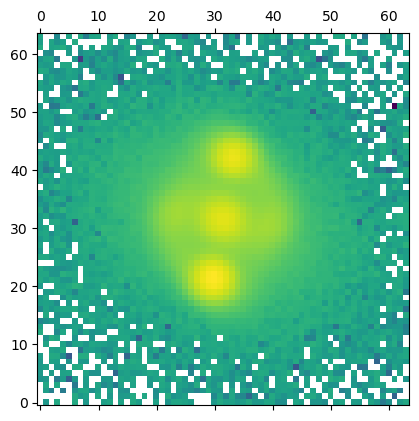

In [11]:
time = 10  # chose a time stamp of the image
image_g = ps_var.image_time(time=time)
image_g += sim_g.noise_for_model(model=image_g)
plt.matshow(np.log10(image_g), origin='lower')
plt.show()